In [1]:
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns

from src import *

set_fonts()

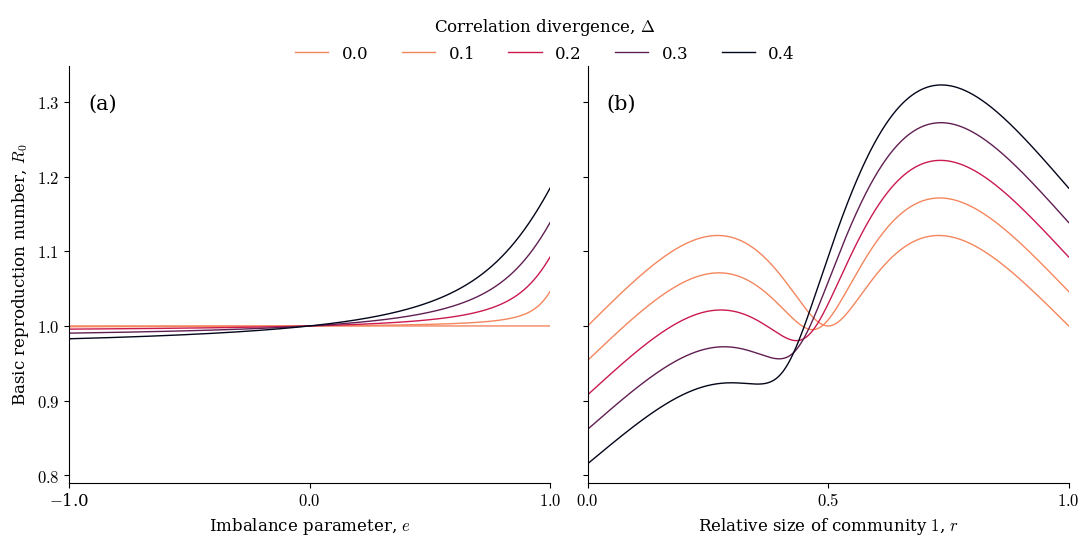

In [2]:
colors = [plt.get_cmap('rocket_r', 5)(i) for i in np.linspace(0.25, 0.8, 5)]#sns.color_palette("blend:#479FF8,#DA3B26", n_colors=5)

eps = np.linspace(0, 3, 100)
dels = np.linspace(0, 3, 100)

k = 10
R0 = 1.0
gamma = 0.1

mean_a = eps @ create_comm(0) @ dels

beta = IBC_beta(mean_a, mean_a, R0, gamma, k, e=0, r=0.5)

rep_num_e = []
for j, e in enumerate(np.linspace(-1, 1, 2001)):
    rep_tmp = []
    for i, del_a in enumerate(np.linspace(0, 0.4, 5)):
        rep_tmp.append(
            IBC_r0(
                mean_a + np.round(del_a, 2),
                mean_a - np.round(del_a, 2),
                beta,
                gamma,
                k,
                e,
                0.5,
            )
        )
    rep_num_e.append(rep_tmp)

beta = IBC_beta(mean_a, mean_a, R0, gamma, k, e=0.8, r=0.5)

rep_num_r = []
for j, r in enumerate(np.linspace(0, 1, 1001)):
    rep_tmp = []
    for i, del_a in enumerate(np.linspace(0, 0.4, 5)):
        rep_tmp.append(
            IBC_r0(
                mean_a + np.round(del_a, 2),
                mean_a - np.round(del_a, 2),
                beta,
                gamma,
                k,
                0.8,
                r,
            )
        )
    rep_num_r.append(rep_tmp)

fig, ax = plt.subplots(figsize=(11, 5), ncols=2, sharey=True)
for i in range(5):
    ax[0].plot(
        np.linspace(-1, 1, 2001),
        [j[i] for j in rep_num_e],
        color=colors[i],
        label=f"{np.round(np.linspace(0, 0.4, 5)[i], 2)}",
        linewidth=1,
    )

    ax[1].plot(
        np.linspace(0, 1, 1001),
        [j[i] for j in rep_num_r],
        color=colors[i],
        label=f"{np.round(np.linspace(0, 0.4, 5)[i], 2)}",
        linewidth=1,
    )

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title=r"Correlation divergence, $\Delta$",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=5,
    frameon=False
)
ax[0].set_xlabel(r"Imbalance parameter, $e$")
ax[0].set_ylabel(r"Basic reproduction number, $R_0$")

ax[0].set_xticks([-1.0, 0.0, 1.0], [r"$-$1.0", r"$0.0$", r"$1.0$"])
ax[0].set_yticks(
    np.linspace(0.8, 1.3, 6),
    labels=[r"$0.8$", r"$0.9$", r"$1.0$", r"$1.1$", r"$1.2$", r"$1.3$"],
)

ax[0].set_xlim(-1, 1)

ax[1].set_xlabel(r"Relative size of community $1$, $r$")

ax[1].set_xticks([0.0, 0.5, 1.0], [r"$0.0$", r"$0.5$", r"$1.0$"])
ax[1].set_yticks(
    np.linspace(0.8, 1.3, 6),
    labels=[r"$0.8$", r"$0.9$", r"$1.0$", r"$1.1$", r"$1.2$", r"$1.3$"],
)

ax[1].set_xlim(0, 1)

ax[0].text(-1 + 0.2, 1.3 + 0.01, "(a)", color="k", ha="right", va="top", fontsize=15)
ax[1].text(0 + 0.1, 1.3 + 0.01, "(b)", color="k", ha="right", va="top", fontsize=15)

sns.despine()
plt.tight_layout()

#plt.savefig("Figures/Figure-3.png", dpi=1000, bbox_inches="tight")
#plt.savefig("Figures/Figure-3.svg", format="svg", bbox_inches="tight")
plt.savefig("Figures/Figure-3.pdf", format="pdf", bbox_inches="tight")